# Coursework 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Linear regression and feature selection <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
  - [(1.3)](#task-13) <a name="index-task-13"></a>
  - [(1.4)](#task-14) <a name="index-task-14"></a>
- [Task 2](#task-2): Non-linear regression with Kernel Ridge Regression <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>
- [Task 3](#task-3): Classification with the Multi-Layer Perceptron <a name="index-task-3"></a>
  - [(3.1)](#task-31) <a name="index-task-31"></a>
  - [(3.2)](#task-32)  <a name="index-task-32"></a>



---



<a name="task-1"></a>

# Task 1: Linear regression and feature selection [(index)](#index-task-1)

In [340]:
# import useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# set global config for matplotlib to make plots readable
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

rng = np.random.default_rng(0)

In [341]:
# load data
data_train = pd.read_csv("asteroid_observations_train.csv")
data_test = pd.read_csv("asteroid_observations_test.csv")

# show the shape of the data
print("train data shape: ", data_train.shape)
print("test data shape: ", data_test.shape)

data_train.head()

train data shape:  (638, 9)
test data shape:  (160, 9)


,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,18.1,0.041,15,2.0,0.201590,11.975800,3.912298,1.573,MBA
1,12.5,0.139,349,7208.0,0.032746,8.793883,11.942668,12.355,TJN
2,14.1,0.062,705,25309.0,0.179314,27.433960,5.749452,8.862,OMB
3,16.9,0.097,91,3805.0,0.066114,13.813845,4.592982,2.139,MBA
4,11.5,0.062,1300,9606.0,0.008824,5.595907,12.006096,30.763,TJN


In [342]:
data_test.head()

,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,16.00,0.061,371,9126.0,0.144324,12.018294,4.266851,3.888,MBA
1,14.20,0.079,528,10262.0,0.049446,20.973974,5.802442,7.860,OMB
2,10.71,0.045,2464,35751.0,0.185255,5.629857,7.950795,45.117,OMB
3,13.00,0.054,1157,9248.0,0.134931,4.428840,7.884727,15.014,OMB
4,15.20,0.075,390,7176.0,0.071674,16.578118,5.460715,5.330,MBA


In [343]:
# features
features = data_test.columns[:-2]
features

Index(['Absolute magnitude', 'Albedo', 'Number of observations',
       'Observation arc length', 'Orbital eccentricity', 'Orbital inclination',
       'Orbital period'],
      dtype='str')

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [344]:
# create data matrix
X_train = np.asarray(data_train.iloc[:, :-2])
X_test = np.asarray(data_test.iloc[:, :-2])

# create label vector
y_train = np.asarray(data_train.loc[:, 'Asteroid diameter'])
y_test = np.asarray(data_test.loc[:, 'Asteroid diameter'])

In [345]:
# standardise data to expection = 0 and standard deviation = 1
def standardise(X, X_train_=None):
    """
    Standardise features.

    Parameters:
        X (np.array): Feature matrix.
        X_train_ (np.array): An optional feature matrix to compute the statistics
            from before applying it to X. If None, just use X to compute the statistics.

    Returns:
        X_std (np.array): Standardised feature matrix
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std

X_train_std = standardise(X=X_train)
X_test_std = standardise(X=X_test, X_train_=X_train)

The solution of the the (ordinary) least squares is
$$
\boldsymbol{\hat{\beta}^{LS}} = (\boldsymbol X^T\boldsymbol X)^{-1}\boldsymbol X^T\boldsymbol y \,,
$$

In the method fit_ols(), we add an interception feature on the first column of the data matrix $X$, so it returns
$$
\boldsymbol{\hat{\beta}^{LS}}  = (\hat{\beta}_{0}^{LS}, \hat{\beta}_{1}^{LS}, \dots, \hat{\beta}_{p}^{LS})^T
$$


In [346]:
# fit the ordinary least squares
def fit_ols(X, y):
    """
    return the beta_ls of OLS problem.
    """
    # check the shape
    N, p = X.shape
    y = np.asarray(y).reshape(-1, 1)
    assert y.shape[0] == N

    # add intercept
    X_aug = np.hstack([np.ones((N, 1)), X])

    # apply formula
    beta_ls = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    assert beta_ls.shape[0] == (p + 1)
    
    return beta_ls.flatten()

For Garrote, $f_{\boldsymbol{\beta}^G,\hat{\beta}_0^{LS}}(x) = x^{T}\boldsymbol{\beta}^G + \hat{\beta}_0^{LS}$ where $\beta^{G}_{j} = g_j\hat{\beta}^{LS}_{j}$

The optimisation problem is:
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}-f_{\beta^G,\hat{\beta}_0^{LS}}\!\left(x^{(i)}\right)\right)^2
\right].
\\
\text{such that }
\lVert_{} \boldsymbol{g}\rVert_{1}=\sum_{j=1}^{p}\lvert g_{j}\rvert < s
\qquad \text{for some } s\in\mathbb{R}_{\ge 0}.
$$
which is equivalent to
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}- {x^{(i)}}^{T} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS}\right)^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$


since we can rewrite $\boldsymbol{\beta}^{G} = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)g$, let $D = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)$, so the optimisation problem is 

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

Replace $\lVert_{} \boldsymbol{g}\rVert_{1}$ by Huber loss $\sum_{i=1}^{p} L_c(g_i)$

$$
L_c (g_i) =
\begin{cases}
 \frac{1}{2}{g^2_i}                   & \text{for } |g_i| \le c, \\
 c (|g_i| - \frac{1}{2}c), & \text{otherwise,}
\end{cases}
$$

$$
\frac{dL_c (g_i)}{d g_i} =
  \begin{cases}
 g_i                   & \text{for } |g_i| \le c, \\
 c\, \text{sign}(g_i) , & \text{otherwise,}
\end{cases}
$$

So the final Loss function is

$$
L(\boldsymbol g) = \frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \sum_{i=1}^{p} L_c(g_i). \\
= \frac{1}{N^{\mathrm{train}}}
(\boldsymbol{y}^T \boldsymbol{y} - \boldsymbol{g}^T (\boldsymbol{X}D)^T \boldsymbol{y} - \boldsymbol{y}^T (\boldsymbol{X}D) \boldsymbol{g}
+ \boldsymbol{g}^T(\boldsymbol{X}D)^T(\boldsymbol{X}D)\boldsymbol{g} \\
- \hat{\beta_0^{LS}} \mathbf{1}^T \boldsymbol y - \hat{\beta_0^{LS}} \boldsymbol{y}^T \mathbf{1} + \hat{\beta_0^{LS}}^2 \mathbf{1}^T\mathbf{1} \\
+ \hat{\beta_0^{LS}} (\mathbf{1}^T \boldsymbol X D) \boldsymbol{g} + \hat{\beta_0^{LS}} \boldsymbol{g}^T (\boldsymbol X D)^T \mathbf{1}) \\
+ \lambda \sum_{i=1}^{p} L_c(g_i)
$$

So the gradient of the loss funtion is
$$
\nabla_{\boldsymbol g}{L} = \frac{2}{N^{\mathrm{train}}} (\boldsymbol X D)^T (\boldsymbol X Dg + \hat{\beta}_0^{LS} \mathbf{1} - \boldsymbol y) + \lambda \nabla_{\boldsymbol g}{L_c}
$$

In [347]:
# huber loss
def huber(g, c_huber=1e-4):
    return np.where(np.abs(g) <= c_huber, (g ** 2) / 2., c_huber * (np.abs(g) - c_huber / 2))

# gradient of huber loss
def grad_huber(g, c_huber=1e-4):
    return  np.where(np.abs(g) <= c_huber, g, c_huber * np.sign(g))

# loss function
def compute_loss(g, X, y, beta, lambd, c_huber=1e-4):
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    assert beta_1_p.shape[0] == p

    # X @ D
    XD = X * beta_1_p

    huber_loss = huber(g, c_huber)
    loss = (1 / N_train) * np.sum((y - XD @ g - beta_0) ** 2) + lambd * np.sum(huber_loss)

    return loss

# gradient of loss function
def grad_loss(g, X, y, beta, lambd, c_huber=1e-4):
    """
    g: (p) vector: parametre of Garrote
    X: (N, p) matrix: data
    y: (N) vector: label
    beta: (p + 1) vector: the learnt parametre of OLS
    lambd: float: regulation parametre
    c_huber: float: smooth parametre
    """
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    assert beta_1_p.shape[0] == p

    # compute the gradient of Huber loss part
    grad_c = grad_huber(g, c_huber=c_huber)

    # compute the gradient of the loss funtion
    XD = X * beta_1_p
    grad = (2 / N_train) * XD.T @ (XD @ g + beta_0 - y) + lambd * grad_c

    return grad

Then we implement gradient descent since there is no analytic for this problem.
$$
\boldsymbol{g}_{t + 1} = \boldsymbol{g}_{t} - \eta_t \nabla_{\boldsymbol g} L(\boldsymbol{g}_{t})

In [348]:
def gradient_descent(X, y, beta, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    N, p = X.shape
    assert y.shape[0] == N

    # initialize the parametre
    g = np.zeros(p)
    nth = 0
    loss_history = []  # Track loss values
    epochs_list = []  # Track epoch numbers

    for epoch in range(1, n_iters + 1):
        # update g
        grad = grad_loss(g, X, y, beta, lambd, c_huber)
        g = g - step_size * grad

        # Check for convergence at 2^nth epoch or last epoch
        if epoch == 2**nth or epoch == n_iters:
            # Compute the current loss
            loss = compute_loss(g, X, y, beta, lambd, c_huber)
            if print_outcome:
                print(f'Epoch: {epoch}, Loss: {loss:.6f}')

            # Update tracking variables
            epochs_list.append(epoch)
            loss_history.append(loss)
            nth += 1

    return g, loss_history, epochs_list

The train process is :
1. fit OLS and get $\hat{\boldsymbol\beta}^{LS}$
2. gradient descent on Garrote problem and get $\boldsymbol g$

In [349]:
def train_garrote(X_train, y_train, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    # check dimention
    N, p = X_train.shape
    assert y_train.shape[0] == N

    # first get the ols coefficient
    beta_LS = fit_ols(X_train, y_train)

    # use gradient descent to get the optimal g
    g, loss_history, epochs_list = gradient_descent(X_train, y_train, beta_LS, lambd, n_iters, step_size, c_huber, print_outcome)

    # get the Garrote coefficient
    beta_G = g * beta_LS[1:]

    return beta_G, beta_LS, g, loss_history, epochs_list

In [350]:
# example
beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train=X_train_std, y_train=y_train, lambd=1e-2, step_size=1e-7, print_outcome=True)

Epoch: 1, Loss: 178.353522
Epoch: 2, Loss: 178.349138
Epoch: 4, Loss: 178.340369
Epoch: 8, Loss: 178.322835
Epoch: 16, Loss: 178.287774
Epoch: 32, Loss: 178.217680
Epoch: 64, Loss: 178.077611
Epoch: 128, Loss: 177.797943
Epoch: 256, Loss: 177.240481
Epoch: 512, Loss: 176.133021
Epoch: 1024, Loss: 173.947637
Epoch: 2048, Loss: 169.692568
Epoch: 4096, Loss: 161.626276
Epoch: 8192, Loss: 147.127278
Epoch: 10000, Loss: 141.358556


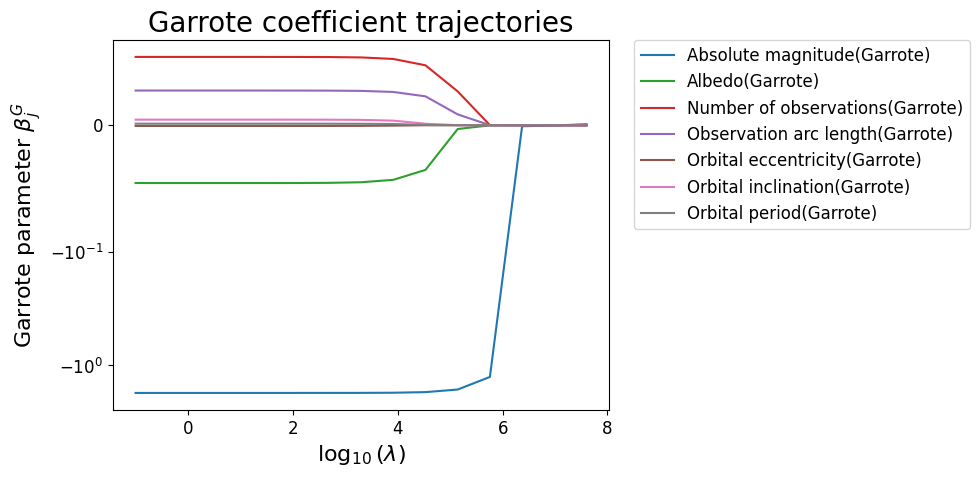

In [351]:
# S_lambda set
S_lambd = np.logspace(-1, 7.6, 15)

# record the parameters of each lambda
beta_list = []
ls_list = []

# train models of different lambda
for lambd in S_lambd:
    beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train_std, y_train, lambd=lambd)
    beta_list.append(beta_G)
    ls_list.append(beta)

all_beta = np.vstack(beta_list) # (Number_of_lambda, Number_of_feature)
all_ls = np.vstack(ls_list)
feature_color = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
# plot each feature
for j in range(all_beta.shape[1]):
    c = feature_color[j]
    plt.plot(np.log10(S_lambd), all_beta[:, j], color=c, label=features[j]+"(Garrote)")
    # plt.plot(np.log10(S_lambd), all_ls[:, j + 1], '--', color=c, label=features[j]+"(OLS)")

plt.yscale("symlog", linthresh=0.1)
plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"Garrote parameter ${\beta}_j^{G}$")
plt.title("Garrote coefficient trajectories")
# plt.legend()
plt.legend(loc=2, bbox_to_anchor=(1.05,1.0),borderaxespad = 0.) 
plt.show()

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In [352]:
def T_fold_split(num_samples, num_folds):
    fold_size = num_samples // num_folds
    indices = np.arange(num_samples)
    folds = [indices[i * fold_size : (i + 1) * fold_size] for i in range(num_folds)]
    return folds

def T_fold_evaluation(X, y, num_folds, S_lambd):
    N, p = X.shape
    assert N == y.shape[0]

    folds = T_fold_split(N, num_folds)
    d_list = []
    for j, lambd in enumerate(S_lambd):
        val_mse_list = []
        for i, val_indice in enumerate(folds):
            # get train set and val set
            train_indices = np.setdiff1d(np.arange(N), val_indice)
            X_train, y_train = X[train_indices], y[train_indices]
            X_val, y_val = X[val_indice], y[val_indice]

            N_val = X_val.shape[0]
            assert N_val == len(val_indice)

            # train
            beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train, y_train, lambd=lambd)

            # compute mse
            mse = np.sum((y_val - X_val @ beta_G - beta[0]) ** 2) / N_val
            val_mse_list.append(mse)

        sumation = 0
        for t in range(1, num_folds):
            sumation += abs(val_mse_list[t] - val_mse_list[t - 1])
        sumation /= num_folds - 1
        d_list.append(sumation)

    return d_list

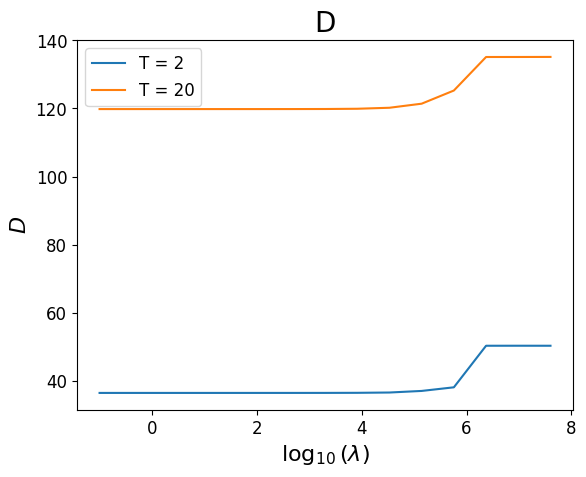

In [353]:
T_list = [2, 20]
for T in T_list:
    d_list = T_fold_evaluation(X_train_std, y_train, T, S_lambd)
    plt.plot(np.log10(S_lambd), d_list, label=r"T = "+f"{T}")

plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"$D$")
plt.title("D")
plt.legend()
plt.show()

<a name="task-13"></a>

## (1.3) [(index)](#index-task-13)

In [354]:
# from week 1 notebook
def minimize_ls_huber(X, y, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    """
    This function estimates the regression parameters with the relaxed version
    of LASSO regression using the gradient-descent algorithm to find the optimal
    solution.
    Args:
    X (np.array): The augmented data matrix with shape (N, p + 1).
    y (np.array): The response column with shape (N, 1).
    lambd (float): The multiplier of the relaxed L1 term.
    n_iters (int): Number of gradient descent iterations.
    step_size (float): The step size in the updating step.
    """

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    X_aug = np.hstack((np.ones((N, 1)), X))
    # Precomputed products to avoid redundant computations.
    XX = X_aug.T @ X_aug
    Xy = X_aug.T @ y
    # Initialize beta params with zeros
    beta = np.zeros(p + 1)

    for i in range(n_iters):
        # Compute the gradient of the relaxed LASSO, Huber.
        grad_c = grad_huber(beta, c_huber)

        # Intercept term is not involved in the regularisation.
        grad_c[0] = 0 ## <-- EDIT THIS LINE

        # Compute the gradient of the regularised loss.
        grad = (2 / N) * (XX @ beta - Xy) + lambd * grad_c ## <-- EDIT THIS LINE

        # Update beta
        beta = beta - step_size * grad ## <-- EDIT THIS LINE

    return beta

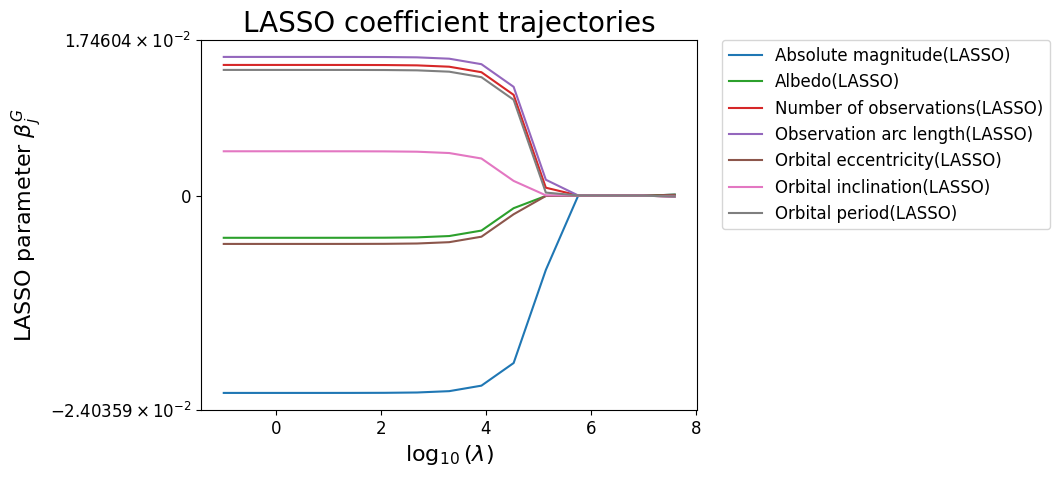

In [355]:
# record the parameters of each lambda
garrote_list = []
ls_list = []
lasso_list = []

# train models of different lambda
for lambd in S_lambd:
    beta_G, beta, g, loss_history, epochs_list = train_garrote(X_train_std, y_train, lambd=lambd)
    beta_lasso = minimize_ls_huber(X_train_std, y_train, lambd=lambd)
    beta_lasso_without_intercept = beta_lasso[1:]
    lasso_list.append(beta_lasso_without_intercept)
    garrote_list.append(beta_G)
    ls_list.append(beta)

all_lasso = np.vstack(lasso_list) # (Number_of_lambda, Number_of_feature)
all_ls = np.vstack(ls_list)
all_garrote = np.vstack(garrote_list)
feature_color = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
# plot each feature
for j in range(all_lasso.shape[1]):
    c = feature_color[j]
    # plt.plot(np.log10(S_lambd), all_garrote[:, j], color=c, label=features[j]+"(Garrote)")
    plt.plot(np.log10(S_lambd), all_lasso[:, j], color=c, label=features[j]+"(LASSO)")
    # plt.plot(np.log10(S_lambd), all_ls[:, j + 1], '--', color=c, label=features[j]+"(OLS)")

plt.yscale("symlog", linthresh=0.1)
plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"LASSO parameter ${\beta}_j^{G}$")
plt.title("LASSO coefficient trajectories")
# plt.legend()
plt.legend(loc=2, bbox_to_anchor=(1.05,1.0),borderaxespad = 0.) 
plt.show()

In [356]:
def bootstrap_feature_selection(X, y, N_prime, lambd, B=100, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    N, p = X.shape
    training_indices = np.arange(N)
    selection_counts = np.zeros(p)

    for b in range(B):
        indices = rng.choice(training_indices, size=N_prime, replace=False)
        X_sample = X[indices]
        y_sample = y[indices]

        beta_lasso = minimize_ls_huber(X_sample, y_sample, lambd, n_iters, step_size, c_huber)
        beta_lasso = beta_lasso[1:]
        selected = np.abs(beta_lasso) > 0.001
        selection_counts += selected

    return selection_counts / B

In [357]:
def plot_prob_trajectory(N_prime, S_lambd):
    prob_list = []

    # get prob of different lambda
    for lambd in S_lambd:
        prob_lasso = bootstrap_feature_selection(X_train_std, y_train, N_prime, lambd=lambd, B=100)
        prob_list.append(prob_lasso)

    all_prob = np.vstack(prob_list)
    feature_color = ['C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
    for j in range(all_prob.shape[1]):
        c = feature_color[j]
        plt.plot(np.log10(S_lambd), all_prob[:, j], color=c, label=features[j]+" Probability")

    plt.yscale("symlog", linthresh=0.1)
    plt.xlabel(r"$\log_{10}(\lambda)$")
    plt.ylabel(r"Probability")
    plt.title("LASSO selection")
    plt.legend(loc=2, bbox_to_anchor=(1.05,1.0),borderaxespad = 0.) 
    plt.xticks(rotation=45)
    plt.show()

def plot_prob_bar(N_prime, lambd):
    plt.figure(figsize=(12, 6))
    prob_lasso = bootstrap_feature_selection(X_train_std, y_train, N_prime, lambd=lambd, B=100)

    plt.bar(features, prob_lasso)
    plt.xlabel('Feature Index')
    plt.ylabel('LASSO prob')
    plt.title('LASSO Coefficients of Features')
    plt.xticks(rotation=45)
    plt.show()

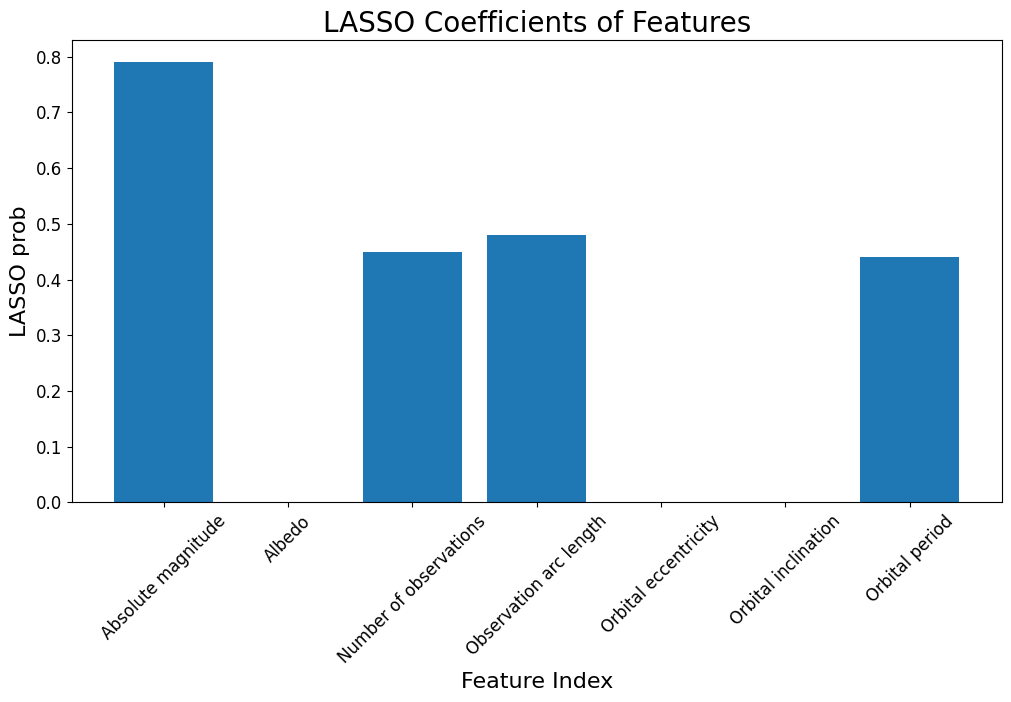

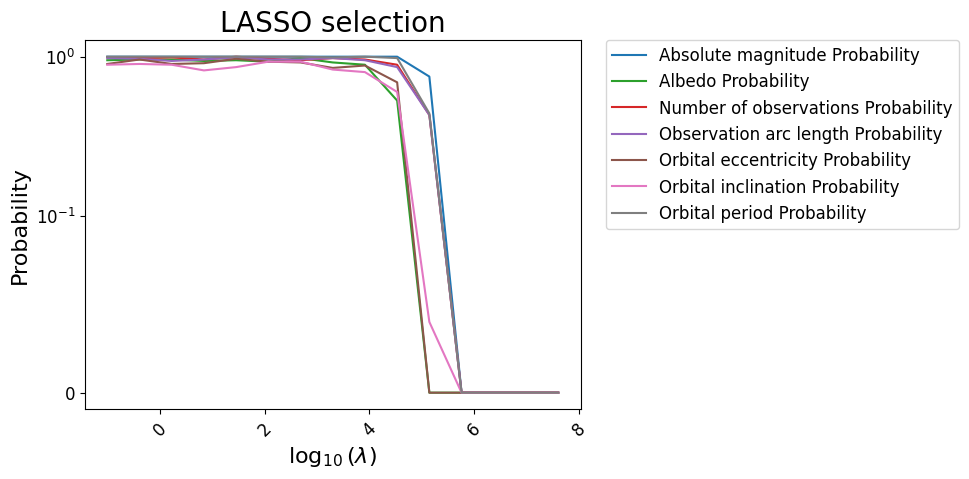

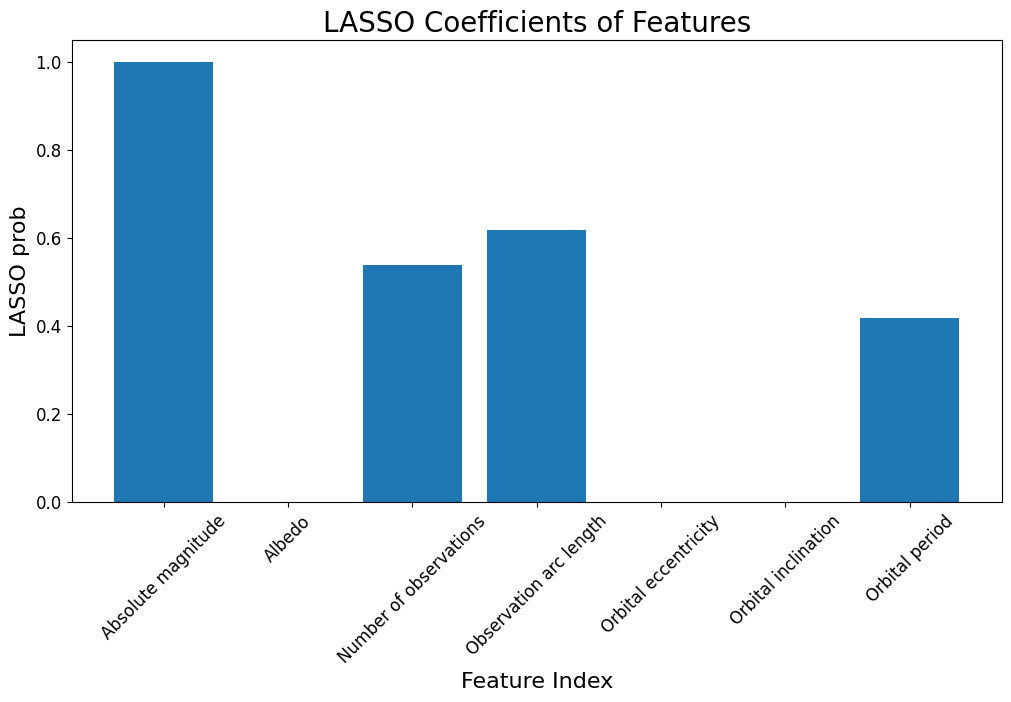

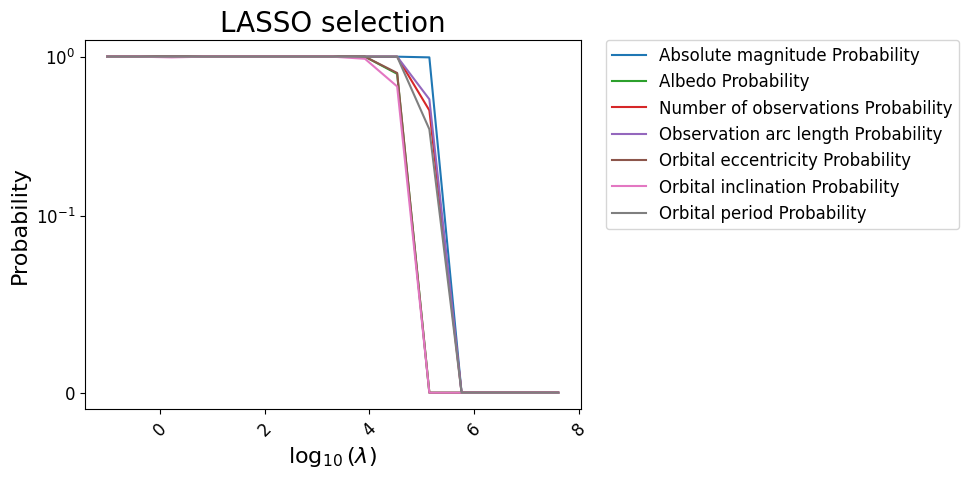

In [358]:
plot_prob_bar(50, S_lambd[10])
plot_prob_trajectory(50, S_lambd)

N_train = X_train_std.shape[0]
plot_prob_bar(N_train // 2, S_lambd[10])
plot_prob_trajectory(N_train // 2, S_lambd)

<a name="task-14"></a>

## (1.4) [(index)](#index-task-14)

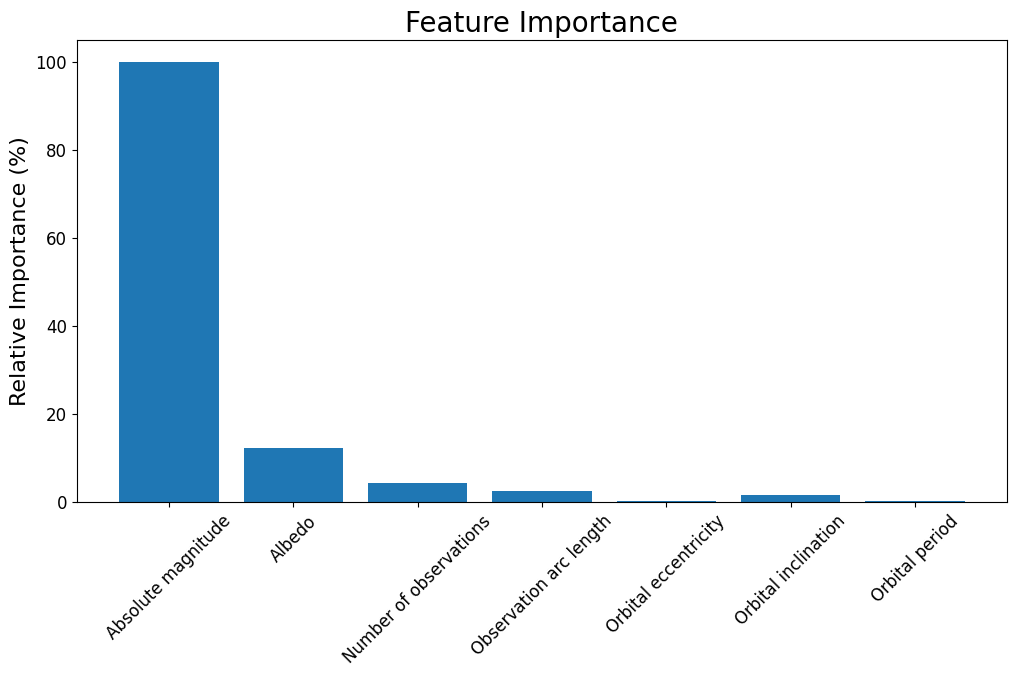

In [359]:
def compute_r2(y_true, y_pred):
    numer = np.sum((y_true - y_pred) ** 2)
    deter = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (numer / deter)

def ls_importance(X_train, y_train, X_test, y_test):
    beta_ls = fit_ols(X_train, y_train)

    X_test_aug = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
    y_test_pred_base = X_test_aug @ beta_ls
    r2_baseline = compute_r2(y_test, y_test_pred_base)

    importance = []
    p = X_test.shape[1]

    for j in range(p):
        X_test_shuffled = X_test.copy()
        rng.shuffle(X_test_shuffled[:, j])

        X_test_shuffle_aug = np.hstack((np.ones((X_test.shape[0], 1)), X_test_shuffled))
        y_test_pred_shuffled = X_test_shuffle_aug @ beta_ls
        r2_shuffled = compute_r2(y_test, y_test_pred_shuffled)

        importance.append(abs(r2_baseline - r2_shuffled))

    importances = np.array(importance)
    max_imp = np.max(importances)
    importance_percent = (importances / max_imp) * 100

    return importance_percent

importance = ls_importance(X_train_std, y_train, X_test_std, y_test)
plt.figure(figsize=(12, 6))
plt.bar(features, importance)
plt.ylabel('Relative Importance (%)')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

<a name="task-2"></a>

# Task 2: Non-linear regression with Kernel Ridge Regression [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)

<a name="task-3"></a>

# Task 3: Classification with the Multi-Layer Perceptron [(index)](#index-task-3)

<a name="task-31"></a>

## (3.1) [(index)](#index-task-31)

<a name="task-32"></a>

## (3.2) [(index)](#index-task-32)